<a href="https://colab.research.google.com/github/pratik5355/House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
DATASET_URL   = "/content/HousingData.csv"

In [57]:
TARGET_COLUMN = "MEDV"
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [59]:
#  1.  LOAD DATA

def load_data(url: str) -> pd.DataFrame:
    print(f"\n{'='*55}")
    print("  STEP 1 — Loading dataset")
    print(f"{'='*55}")

    if url == " ":
        raise ValueError(

            "script to a valid file path or URL before running."
        )

    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(url, sep=sep, engine="python")
            if df.shape[1] > 1:
                print(f"  Loaded {df.shape[0]} rows × {df.shape[1]} columns")
                return df
        except Exception:
            continue

    raise IOError(f"[ERROR] Could not parse the file at: {url}")

In [60]:
#  2.  PREPROCESS
def preprocess(df: pd.DataFrame):
    print(f"\n{'='*55}")
    print("  STEP 2 — Preprocessing")
    print(f"{'='*55}")

    if TARGET_COLUMN not in df.columns:
        raise ValueError(f"[ERROR] Column '{TARGET_COLUMN}' not found.")

    # Keep numeric columns only
    df = df.select_dtypes(include=[np.number]).copy()

    # Impute missing values with column median
    imputer = SimpleImputer(strategy="median")
    df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

    print(f"  Missing values   : imputed with median")
    print(f"  Features used    : {[c for c in df.columns if c != TARGET_COLUMN]}")

    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print(f"  Train size       : {X_train.shape[0]}")
    print(f"  Test  size       : {X_test.shape[0]}")

    return X_train, X_test, y_train, y_test, list(X.columns)


In [61]:
#  3.  TRAIN
def train(X_train, y_train) -> LinearRegression:
    print(f"\n{'='*55}")
    print("  STEP 3 — Training Linear Regression model")
    print(f"{'='*55}")

    model = LinearRegression()
    model.fit(X_train, y_train)

    print("  Model trained successfully.")
    return model


In [62]:
#  4.  EVALUATE

def evaluate(model: LinearRegression, X_test, y_test, feature_names: list):
    print(f"\n{'='*55}")
    print("  STEP 4 — Evaluation")
    print(f"{'='*55}")

    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n  R²   : {r2:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")

    print(f"\n  Intercept : {model.intercept_:.4f}")
    print(f"\n  Coefficients:")
    for feat, coef in zip(feature_names, model.coef_):
        print(f"    {feat:<10} : {coef:>10.4f}")

    return y_pred, mae, rmse, r2

In [63]:
#  5.  VISUALISE
def visualise(y_test, y_pred, feature_names: list, model: LinearRegression):
    print(f"\n{'='*55}")
    print("  STEP 5 — Plots")
    print(f"{'='*55}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Linear Regression — House Price Prediction",
                 fontsize=13, fontweight="bold")

    # (a) Actual vs Predicted
    ax = axes[0]
    ax.scatter(y_test, y_pred, alpha=0.6, color="#2196F3", edgecolors="none", s=25)
    lims = [min(y_test.min(), y_pred.min()) - 1,
            max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual MEDV")
    ax.set_ylabel("Predicted MEDV")
    ax.set_title("Actual vs Predicted")
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f"R² = {r2:.4f}", transform=ax.transAxes,
            fontsize=10, color="#1B5E20",
            bbox=dict(boxstyle="round,pad=0.3", fc="#E8F5E9", ec="#4CAF50"))
    ax.legend(fontsize=8)

    # (b) Residuals
    residuals = y_test - y_pred
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.6, color="#FF7043", edgecolors="none", s=25)
    ax.axhline(0, color="black", lw=1.5, linestyle="--")
    ax.set_xlabel("Predicted MEDV")
    ax.set_ylabel("Residual")
    ax.set_title("Residual Plot")

    # (c) Coefficients bar chart
    ax = axes[2]
    colors = ["#E53935" if c < 0 else "#43A047" for c in model.coef_]
    ax.barh(feature_names, model.coef_, color=colors, edgecolor="white")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Coefficient value")
    ax.set_title("Feature Coefficients")

    plt.tight_layout()
    plt.savefig("linear_regression_results.png", dpi=150)
    plt.show()
    print("  Saved → linear_regression_results.png")

In [64]:
#  6.  PREDICT A NEW SAMPLE
def predict_new(model: LinearRegression, feature_names: list):
    print(f"\n{'='*55}")
    print("  STEP 6 — Predict a new sample (demo)")
    print(f"{'='*55}")

    # Sample based on first row of the dataset — change values as needed
    sample = {
        "CRIM": 0.00632, "ZN": 18.0,  "INDUS": 2.31,  "CHAS": 0,
        "NOX":  0.538,   "RM": 6.575, "AGE":   65.2,  "DIS":  4.09,
        "RAD":  1,       "TAX": 296.0,"PTRATIO":15.3, "B":    396.9,
        "LSTAT":4.98,
    }

    sample_df  = pd.DataFrame([[sample[f] for f in feature_names]], columns=feature_names)
    prediction = model.predict(sample_df)[0]

    print(f"\n  Input  : { {f: sample[f] for f in feature_names} }")
    print(f"\n  Predicted MEDV : {prediction:.2f}  (i.e. {prediction * 1000:,.0f})")


  STEP 1 — Loading dataset
  Loaded 506 rows × 14 columns

  STEP 2 — Preprocessing
  Missing values   : imputed with median
  Features used    : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
  Train size       : 404
  Test  size       : 102

  STEP 3 — Training Linear Regression model
  Model trained successfully.

  STEP 4 — Evaluation

  R²   : 0.6591
  MAE  : 3.1487
  RMSE : 4.9999

  Intercept : 28.1680

  Coefficients:
    CRIM       :    -0.1126
    ZN         :     0.0282
    INDUS      :    -0.0257
    CHAS       :     3.2795
    NOX        :   -15.9783
    RM         :     4.7171
    AGE        :    -0.0182
    DIS        :    -1.5062
    RAD        :     0.2182
    TAX        :    -0.0091
    PTRATIO    :    -0.8900
    B          :     0.0120
    LSTAT      :    -0.4442

  STEP 5 — Plots


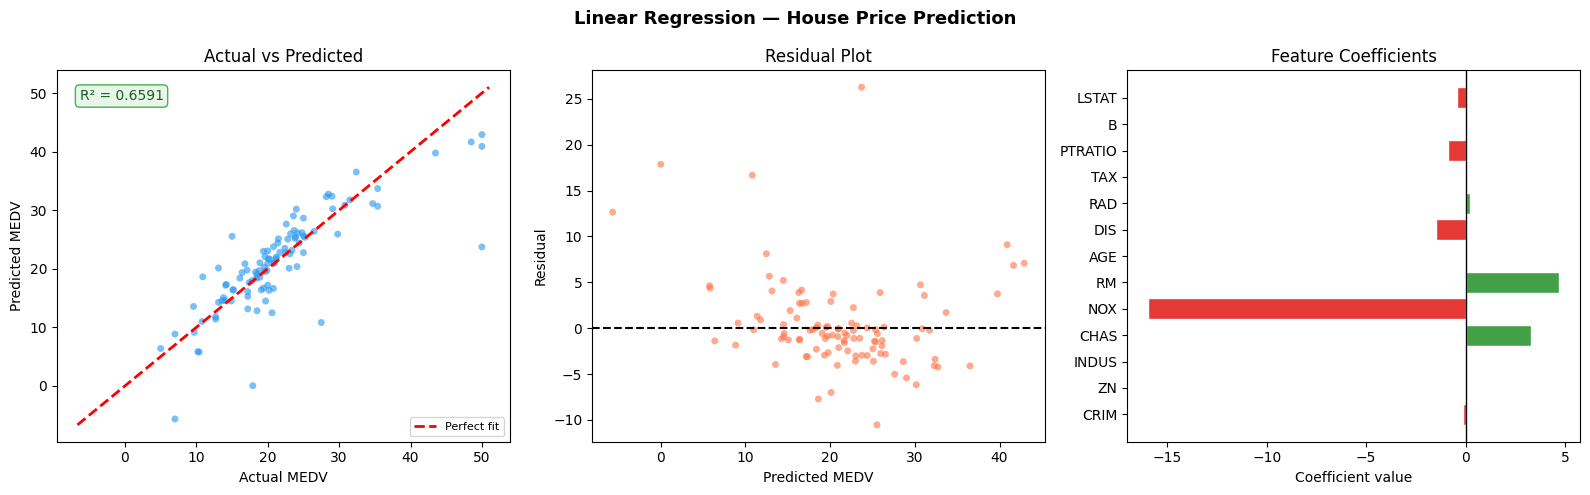

  Saved → linear_regression_results.png

  STEP 6 — Predict a new sample (demo)

  Input  : {'CRIM': 0.00632, 'ZN': 18.0, 'INDUS': 2.31, 'CHAS': 0, 'NOX': 0.538, 'RM': 6.575, 'AGE': 65.2, 'DIS': 4.09, 'RAD': 1, 'TAX': 296.0, 'PTRATIO': 15.3, 'B': 396.9, 'LSTAT': 4.98}

  Predicted MEDV : 30.17  (i.e. 30,173)
  Done!


In [65]:
#  MAIN
def main():
    df                                      = load_data(DATASET_URL)
    X_train, X_test, y_train, y_test, feats = preprocess(df)
    model                                   = train(X_train, y_train)
    y_pred, mae, rmse, r2                   = evaluate(model, X_test, y_test, feats)
    visualise(y_test, y_pred, feats, model)
    predict_new(model, feats)


    print("  Done!")



if __name__ == "__main__":
    main()